# Importar Librerías y Cargar Data

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import math

In [137]:
PATH = r'C:\Users\Nico\proyecto_ml\data\raw\churn_sintetico.csv'

df_raw = pd.read_csv(PATH)
df = df_raw.copy()
df.head()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


# EDA

In [138]:
print("EXPLORACIÓN INICIAL DE LOS DATOS")
print("=" * 50)

# Dimensionalidad
print(f"→ Dimensionalidad: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
print("─" * 50)

# Tipos de columnas
print("Tipos de columnas:")
display(pd.DataFrame(df.dtypes, columns=['Tipo de dato']).rename_axis('Columna'))
print("─" * 50)



# --- Nulos y duplicados ---
print("→ Comprobación de nulos y duplicados\n")

# Valores nulos
print("- Valores nulos por columna:")
display(pd.DataFrame(df.isnull().sum(), columns=['Cantidad de nulos']).rename_axis('Columna'))

# Filas duplicadas
print("─" * 50)
print(f"- Filas duplicadas en el dataset: {df.duplicated().sum()}")
print("─" * 50)

# Distribución de Churn
print("→ Distribución de la variable objetivo 'Churn':")
display(pd.DataFrame(df['churn'].value_counts()))
print("─" * 50)


# Describe
print("\n→ Estadísticas descriptivas:")
display(df.describe())


EXPLORACIÓN INICIAL DE LOS DATOS
→ Dimensionalidad: 5,000 filas × 16 columnas
──────────────────────────────────────────────────
Tipos de columnas:


,Tipo de dato
Columna,
tenure_months,int64
monthly_charge,float64
total_charges,float64
support_tickets,int64
late_payments,int64
avg_monthly_usage_gb,float64
contract_type,str
payment_method,str
internet_service,str


──────────────────────────────────────────────────
→ Comprobación de nulos y duplicados

- Valores nulos por columna:


,Cantidad de nulos
Columna,
tenure_months,0
monthly_charge,0
total_charges,0
support_tickets,0
late_payments,0
avg_monthly_usage_gb,0
contract_type,0
payment_method,0
internet_service,0


──────────────────────────────────────────────────
- Filas duplicadas en el dataset: 0
──────────────────────────────────────────────────
→ Distribución de la variable objetivo 'Churn':


,count
churn,
0,3298
1,1702


──────────────────────────────────────────────────

→ Estadísticas descriptivas:


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,has_streaming,has_security_pack,num_products,customer_age,is_promo,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,36.407200,65.273282,2371.156582,1.710400,0.69700,120.528458,0.668000,0.539800,2.516400,47.825800,0.386200,0.340400
std,20.839776,17.963425,1555.943231,1.304788,0.84388,49.745297,0.470978,0.498463,1.111746,17.615684,0.486926,0.473891
min,1.000000,15.000000,50.000000,0.000000,0.00000,5.000000,0.000000,0.000000,1.000000,18.000000,0.000000,0.000000
25%,18.000000,53.060000,1100.357500,1.000000,0.00000,86.505000,0.000000,0.000000,2.000000,32.000000,0.000000,0.000000
50%,36.000000,64.965000,2162.810000,2.000000,0.00000,120.030000,1.000000,1.000000,3.000000,48.000000,0.000000,0.000000
75%,55.000000,77.362500,3432.657500,2.000000,1.00000,154.100000,1.000000,1.000000,4.000000,63.000000,1.000000,1.000000
max,72.000000,127.170000,9083.060000,8.000000,5.00000,324.400000,1.000000,1.000000,4.000000,78.000000,1.000000,1.000000


A simple vista, parece estar todo bien. Sin nulos, ni duplicados. Tipos de Datos correctos.

In [139]:
#Variable objetivo
print("- Distribución de la variable objetivo:")
print(f"Churn = {df[df['churn'] == 1].shape[0]}")
print(f"No Churn = {df[df['churn'] == 0].shape[0]}")
print("-"*20)
tasa_churn = df['churn'].mean()
print(f"Tasa de Churn: {tasa_churn:.2%}")

- Distribución de la variable objetivo:
Churn = 1702
No Churn = 3298
--------------------
Tasa de Churn: 34.04%


Bien, las clases estan desbalanceadas como cabe esperar en casos de churn

## Comprobación visual Outliers (Tukey)

<Axes: >

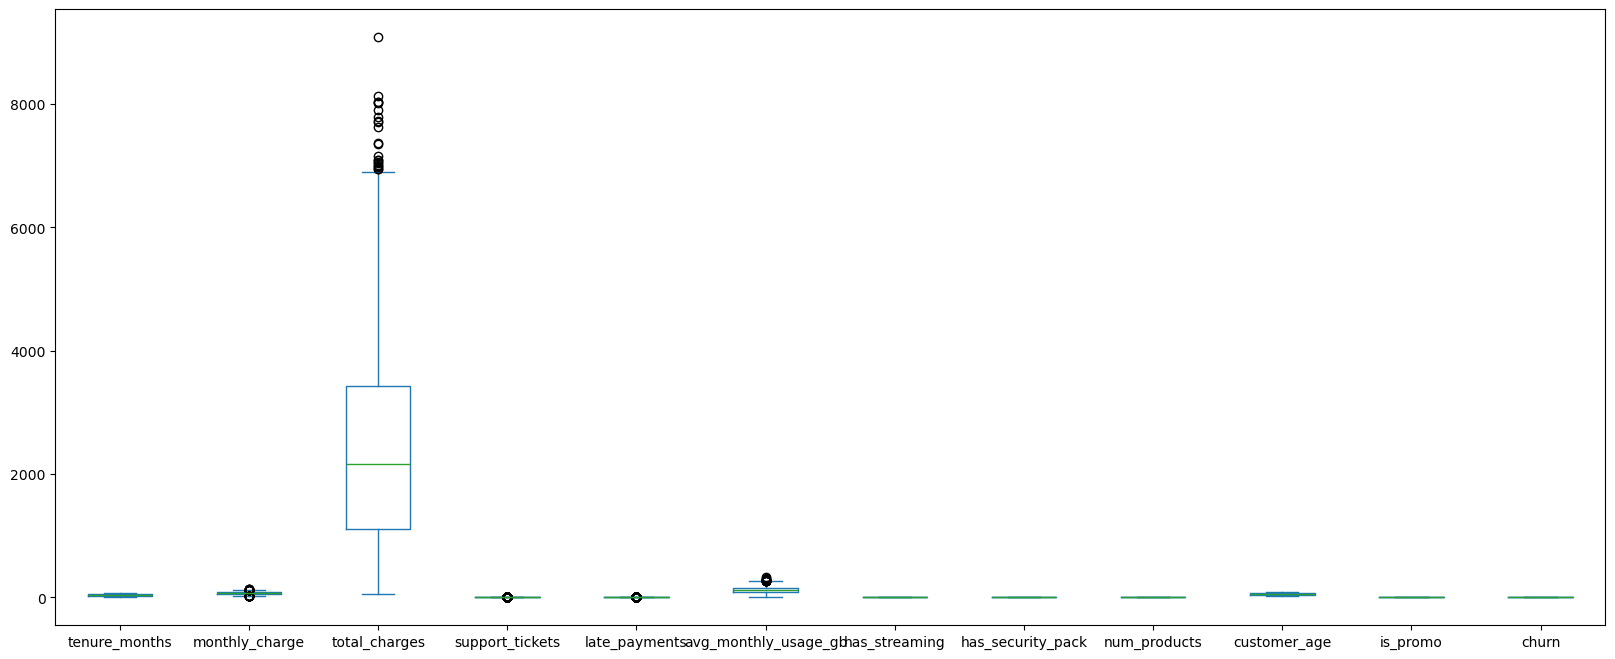

In [140]:
df_num = df.select_dtypes("number")
df_num.plot(kind="box", figsize=(20, 8))

In [141]:
df_num[['monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb' ]].describe()

,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,65.273282,2371.156582,1.710400,0.69700,120.528458
std,17.963425,1555.943231,1.304788,0.84388,49.745297
min,15.000000,50.000000,0.000000,0.00000,5.000000
25%,53.060000,1100.357500,1.000000,0.00000,86.505000
50%,64.965000,2162.810000,2.000000,0.00000,120.030000
75%,77.362500,3432.657500,2.000000,1.00000,154.100000
max,127.170000,9083.060000,8.000000,5.00000,324.400000


## Análisis variable Total Charges

<Axes: >

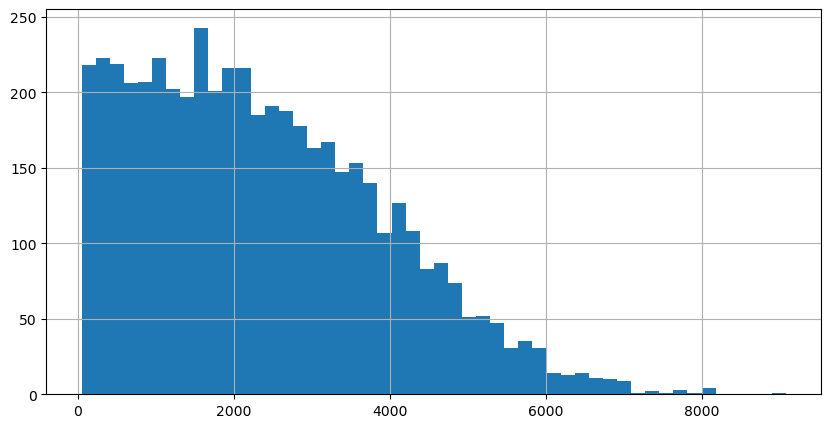

In [142]:
df['total_charges'].hist(bins=50, figsize=(10, 5))

Dado que la variable total_charges presenta una asimetría extrema, con un valor máximo de 9083 que triplica al tercer cuartil (3432), optamos por transformarla en categorías (Bajo, Medio, Alto, VIP).


Dado que la variable total_charges presenta una asimetría extrema, con valores que triplican el promedio general, optamos por transformarla en categorías (Bajo, Medio, Alto, VIP).

Esta decisión se tomó para evitar que los valores excesivamente altos distorsionen el modelo y afecten la precisión de los resultados. Al pasar los datos a categorías, eliminamos el ruido de los valores atípicos pero conservamos la información clave sobre el nivel de consumo de cada cliente.

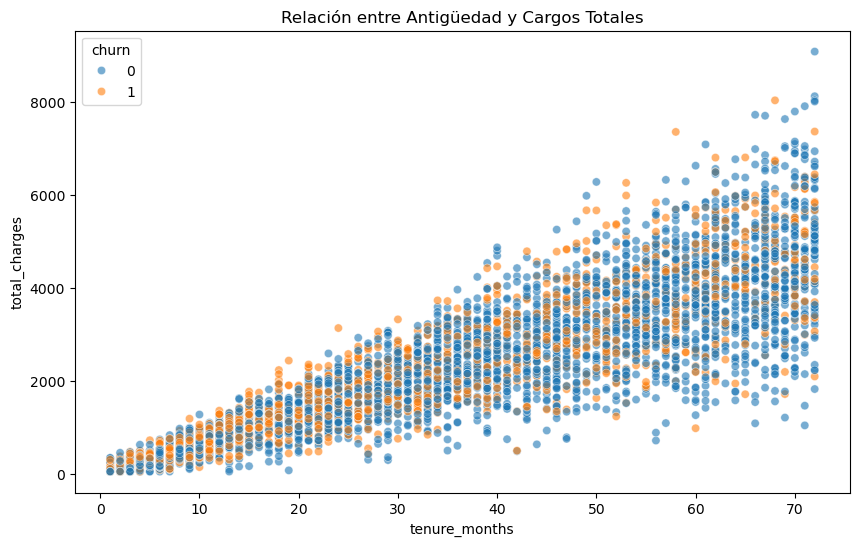

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure_months', y='total_charges', hue='churn', alpha=0.6)
plt.title('Relación entre Antigüedad y Cargos Totales')
plt.show()

La relación es muy lineal, total_charges es casi una "copia" de tenure_months. Lo que tiene sentido dado que a mayor cantidad de meses en la empresa, mayor cantidad de cargas totales. 

<Axes: >

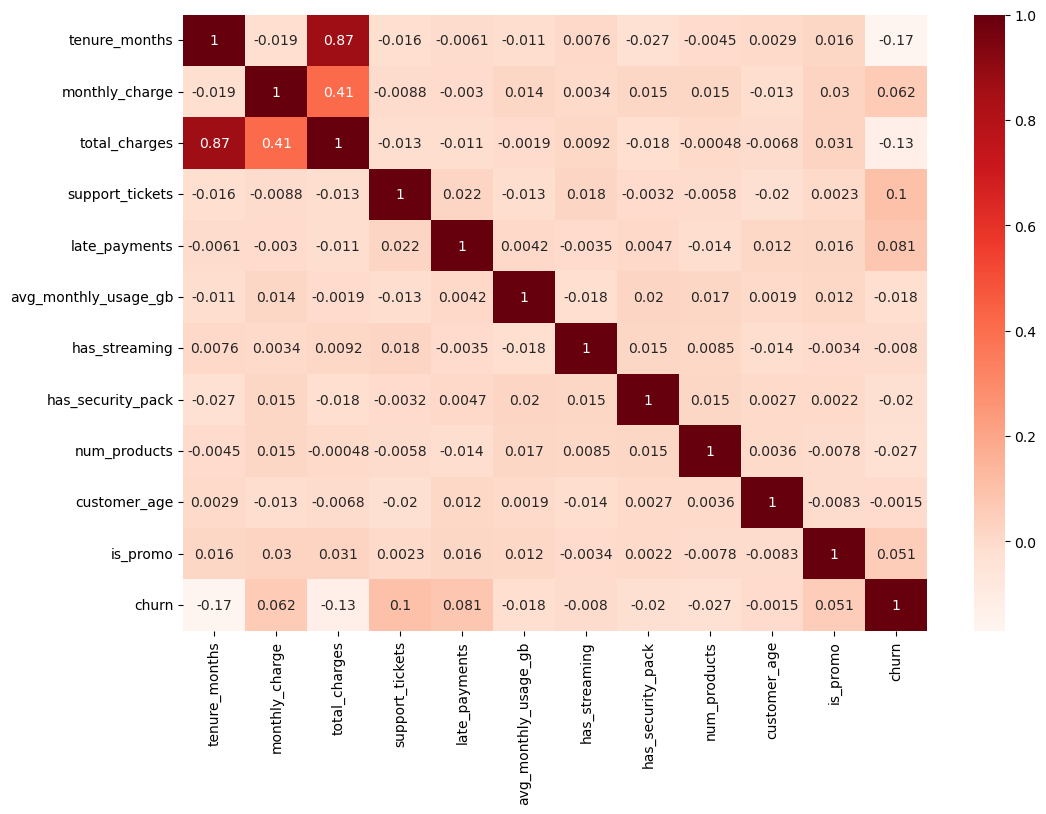

In [144]:
corr = df_num.corr()

fig = plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='Reds')

Como pensabamos, mucha correlación entre total_charges y tenure, además de con monthly charges

C:\Users\Nico\AppData\Local\Temp\ipykernel_14772\501563891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')


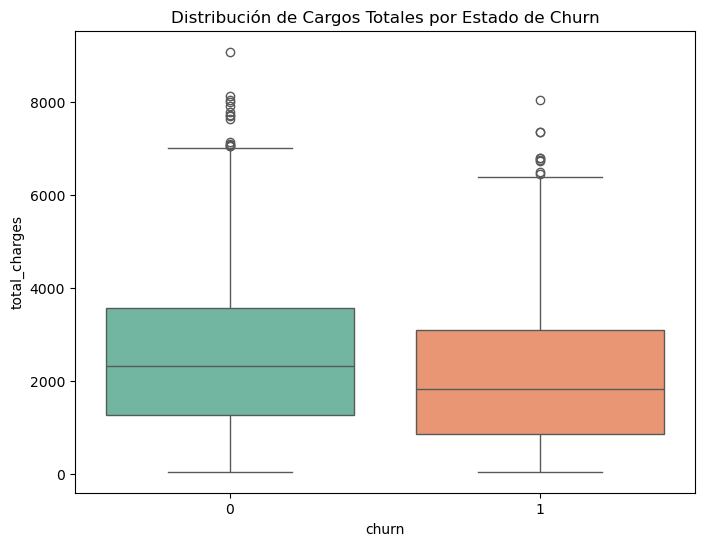

In [145]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')
plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.show()

muy parecidos, pero churn 0 tiene valores más altos (clientes Altos o VIP)

In [146]:
# Definimos los cortes exactos de tus cuartiles
q1 = df['total_charges'].quantile(0.25)
q2 = df['total_charges'].quantile(0.50)
q3 = df['total_charges'].quantile(0.75)

# Función de segmentación
def segmentar_total_charges(x):
    if x <= q1: return 'Bajo'
    if x <= q2: return 'Medio-Bajo'
    if x <= q3: return 'Medio-Alto'
    return 'Alto/VIP'

# Aplicar al dataframe
df['total_charges_cat'] = df['total_charges'].apply(segmentar_total_charges)
orden = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']

In [147]:
df.columns

Index(['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets',
       'late_payments', 'avg_monthly_usage_gb', 'contract_type',
       'payment_method', 'internet_service', 'has_streaming',
       'has_security_pack', 'num_products', 'region', 'customer_age',
       'is_promo', 'churn', 'total_charges_cat'],
      dtype='str')

C:\Users\Nico\AppData\Local\Temp\ipykernel_14772\2700745714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')


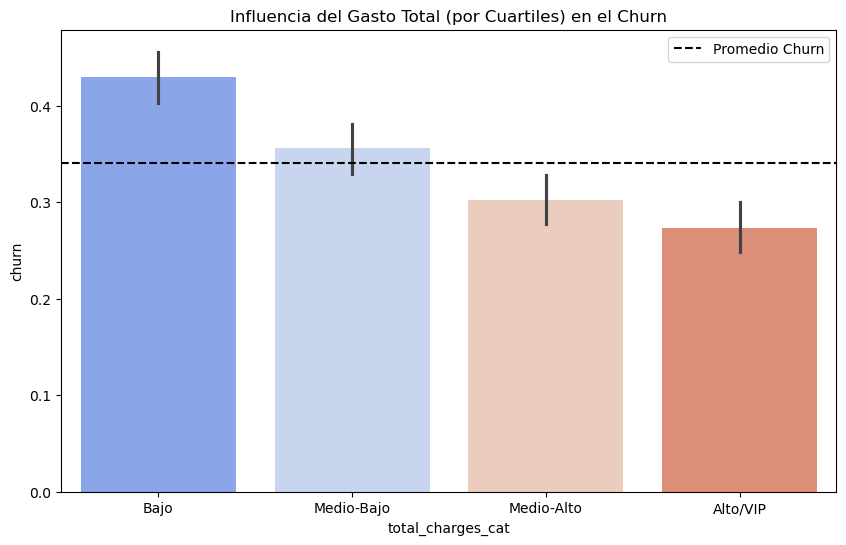

In [148]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')

plt.title('Influencia del Gasto Total (por Cuartiles) en el Churn')
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Promedio Churn')
plt.legend()
plt.show()

Muy bueno! A mayor gasto total acumulado, menor es la tasa de churn.

Nota: Eliminar total_charges del dataset

## Análisis support_tickets

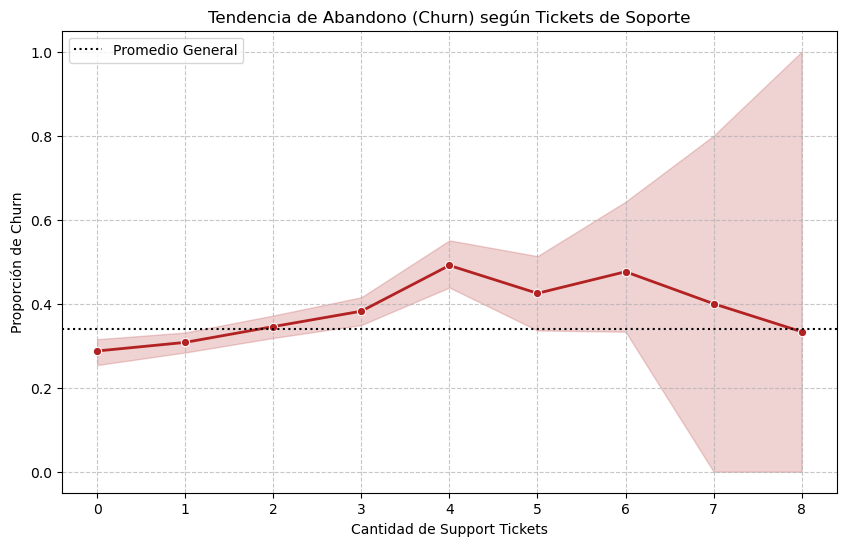

In [149]:

plt.figure(figsize=(10, 6))

# Graficamos la tendencia de Churn según la cantidad de tickets
sns.lineplot(data=df, x='support_tickets', y='churn', marker='o', color='firebrick', linewidth=2)

plt.title('Tendencia de Abandono (Churn) según Tickets de Soporte')
plt.xlabel('Cantidad de Support Tickets')
plt.ylabel('Proporción de Churn')
plt.grid(True, linestyle='--', alpha=0.7)

# Añadimos la línea del promedio general para comparar
plt.axhline(df['churn'].mean(), color='black', linestyle=':', label='Promedio General')
plt.legend()

plt.show()

In [150]:
df['support_tickets'].value_counts()

support_tickets
1    1536
2    1366
0     894
3     756
4     285
5     113
6      42
7       5
8       3
Name: count, dtype: int64

In [151]:
# Creamos una copia para no perder la original por ahora
df['tickets_grouped'] = df['support_tickets'].copy()

# Agrupamos todo lo que sea 5 o más
df.loc[df['tickets_grouped'] >= 5, 'tickets_grouped'] = 5

# Verificamos la nueva distribución
print(df['tickets_grouped'].value_counts().sort_index())

tickets_grouped
0     894
1    1536
2    1366
3     756
4     285
5     163
Name: count, dtype: int64


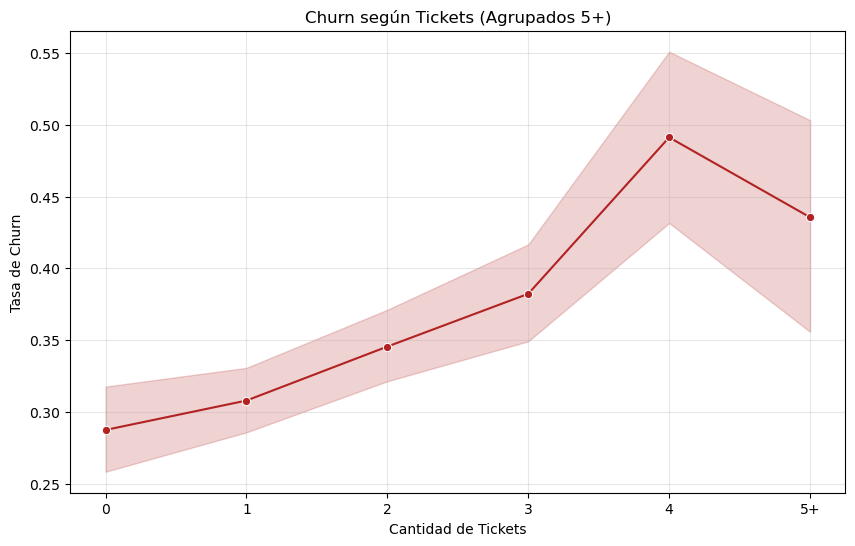

In [152]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='tickets_grouped', y='churn', marker='o', color='firebrick')

plt.title('Churn según Tickets (Agrupados 5+)')
plt.xticks(range(6), ['0', '1', '2', '3', '4', '5+'])
plt.xlabel('Cantidad de Tickets')
plt.ylabel('Tasa de Churn')
plt.grid(True, alpha=0.3)
plt.show()

Se identificó un umbral crítico de deserción al alcanzar los 4 tickets de soporte, donde la tasa de abandono se duplica respecto a los clientes sin incidencias. Se recomienda implementar un protocolo de fidelización proactiva a partir del tercer ticket para mitigar este comportamiento.

## Incidencia de variables categóricas en el 'churn'

In [153]:
#ver relacion de churn con variables categoricas

cols = df.select_dtypes(exclude='number').columns

data = []

for col in cols:
    tabla = (df.groupby(col)['churn'].mean().sort_values(ascending=False).reset_index().rename(columns={'churn': 'churn_rate'}))

    print(f"\n{col.upper()}")
    display(tabla.style.format({'churn_rate': '{:.2%}'}).background_gradient(subset='churn_rate', cmap='Reds'))


CONTRACT_TYPE


,contract_type,churn_rate
0,mensual,47.53%
1,anual,21.12%
2,bianual,11.56%



PAYMENT_METHOD


,payment_method,churn_rate
0,efectivo,40.54%
1,debito,34.32%
2,transferencia,32.73%
3,credito,32.03%



INTERNET_SERVICE


,internet_service,churn_rate
0,movil,50.90%
1,cable,34.79%
2,ninguno,28.78%
3,fibra,26.83%



REGION


,region,churn_rate
0,centro,34.49%
1,sur,34.05%
2,oeste,33.86%
3,norte,33.48%



TOTAL_CHARGES_CAT


,total_charges_cat,churn_rate
0,Bajo,42.96%
1,Medio-Bajo,35.60%
2,Medio-Alto,30.24%
3,Alto/VIP,27.36%


Región bastante parecido. contract_type, payment_method e internet_service tienen bastante incidencia.

Podría hacer una especie de cluster, que ayude a segmentar a los clientes

# Feature engineering

In [154]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans

# features categóricas
X = df[['internet_service', 'contract_type', 'payment_method']]

# one-hot
X_encoded = OneHotEncoder(sparse_output=False).fit_transform(X)

# 🔥 método del codo automático
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_encoded).inertia_ for k in range(1, 11)]
k_opt = np.argmax(np.diff(np.diff(inertia))) + 2

print("K óptimo:", k_opt)

# kmeans final
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['customer_segment'] = kmeans.fit_predict(X_encoded)

# análisis churn por segmento
print(df.groupby('customer_segment')['churn'].mean().sort_values())

K óptimo: 2
customer_segment
0    0.175556
1    0.475273
Name: churn, dtype: float64


In [155]:
# Borramos las originales para quedarnos con las categorizadas/agrupadas
df.drop(columns=['total_charges', 'support_tickets'], inplace=True)

# Verificamos que se hayan ido
print(df.columns)

Index(['tenure_months', 'monthly_charge', 'late_payments',
       'avg_monthly_usage_gb', 'contract_type', 'payment_method',
       'internet_service', 'has_streaming', 'has_security_pack',
       'num_products', 'region', 'customer_age', 'is_promo', 'churn',
       'total_charges_cat', 'tickets_grouped', 'customer_segment'],
      dtype='str')


In [156]:
contract_dummies = pd.get_dummies(df['contract_type'], prefix='contract_type')
df['riesgo_contrato'] = contract_dummies['contract_type_mensual'] / (df['tenure_months'] + 1)

In [157]:
cols_servicios = [col for col in df.columns if col.startswith('has_')]

df['num_servicios'] = df[cols_servicios].sum(axis=1)

In [158]:
if 'late_payments' in df.columns and 'tickets_grouped' in df.columns:
    df['cliente_problematico'] = (
        (df['late_payments'] + df['tickets_grouped']) > 0
    ).astype(int)

# Data Preprocessing


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# --- A. Ordinal Encoding (Jerarquía de gasto acumulado) ---
orden_gasto = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']
encoder_ord = OrdinalEncoder(categories=[orden_gasto])

df['total_charges_cat'] = encoder_ord.fit_transform(df[['total_charges_cat']])

# --- B. One-Hot Encoding (Variables sin orden jerárquico) ---
nominales = ['contract_type', 'payment_method', 'internet_service', 'region']
df = pd.get_dummies(df, columns=nominales, drop_first=True)

In [162]:
num_cols = [
    'tenure_months',
    'monthly_charge',
    'avg_monthly_usage_gb',
    'customer_age',
    'num_products',
    'tickets_grouped',
    'riesgo_contrato',
    'late_payments'
]

In [ ]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Modelos